### Data Loading and Document Construction


In [26]:
# Packages prepared for LDA
import pandas as pd
import numpy as np
import re
from pathlib import Path
import time

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#  NLTK resources 
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('names', quiet=True) 

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

Input data from data cleaning process:


In [ ]:
project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.git').exists())
INPUT = project_root / 'data' / 'processed' / 'Executives_Earnings_Latest_PreEvent.csv'
df=pd.read_csv(INPUT)

Combine all text for each company into a single document

In [28]:
firm_docs = (
    df.groupby(['companyid', 'companyname'])['text']
    .apply(lambda texts: ' '.join(str(t) for t in texts))
    .reset_index()
    .rename(columns={'text': 'document'})
)

print(f"Firm documents: {len(firm_docs)}")
print(f"\nDocument length stats (in characters):")
print(firm_docs['document'].str.len().describe().round(0))
print(f"\nDocument length stats (in words):")
word_counts = firm_docs['document'].str.split().str.len()
print(word_counts.describe().round(0))

Firm documents: 400

Document length stats (in characters):
count       400.0
mean      34129.0
std       12179.0
min        7341.0
25%       25822.0
50%       33478.0
75%       41192.0
max      147699.0
Name: document, dtype: float64

Document length stats (in words):
count      400.0
mean      5741.0
std       2135.0
min       1204.0
25%       4276.0
50%       5564.0
75%       6961.0
max      26679.0
Name: document, dtype: float64


---

## LDA-based Topic Modeling

This section trains Latent Dirichlet Allocation on firm-level earnings-call
documents (400 firms, each firm's entire pre-event transcript concatenated 
into a single document) to discover latent topics and measure each firm's
topic loadings.

**Pipeline**
1. K-value scan using perplexity (K ∈ {6, 8, 10, 12, 15, 18})
2. Qualitative review of top words per topic
3. Final model: K=12 (chosen for clearest AI-narrative separability)
4. Identification of AI-related topics: those whose top-15 words contain
   AI seed vocabulary
5. Aggregation: `ai_topic_loading_sum` = sum of loadings on AI-related topics

---

Text preprocessing and LDA topic modeling

In [29]:
from nltk.corpus import names as nltk_names
#Text cleaning
lemmatizer = WordNetLemmatizer()

# Build stopword set
base_stopwords = set(stopwords.words('english'))

# Domain-specific stopwords: filler words common in earnings calls
earnings_call_stopwords = {
    # Filler / conversational
    'yes', 'yeah', 'okay', 'ok', 'thank', 'thanks', 'hi', 'hello', 'goodbye',
    'please', 'sorry', 'right', 'sure', 'well', 'just', 'kind', 'sort',
    # Meta-references to the call itself
    'call', 'question', 'questions', 'operator', 'participant', 'speaker',
    'earnings', 'quarter', 'year', 'today', 'morning', 'afternoon',
    # Generic business words that appear in almost every call (noise)
    'company', 'business', 'think', 'going', 'know', 'like', 'said', 'say',
    'look', 'looking', 'see', 'seeing', 'get', 'got', 'want', 'would',
    'could', 'should', 'one', 'two', 'first', 'second', 'also',
    # Time/numbers references
    'q1', 'q2', 'q3', 'q4', 'fiscal',
}
name_stopwords = {name.lower() for name in nltk_names.words()}

# URL/web fragments left over after punctuation stripping
web_stopwords = {
    'www', 'http', 'https', 'com', 'net', 'org', 'html',
    'url', 'link', 'page', 'website',
}

ALL_STOPWORDS = (
    base_stopwords
    | earnings_call_stopwords
    | name_stopwords
    | web_stopwords
)

print(f"Total stopwords: {len(ALL_STOPWORDS)} "
      f"({len(base_stopwords)} base + {len(earnings_call_stopwords)} domain + "
      f"{len(name_stopwords)} names + {len(web_stopwords)} web)")


def preprocess_document(text):
    """
    Clean and tokenize a single document for LDA.
    Steps:
    1. Lowercase
    2. Remove numbers and punctuation
    3. Tokenize (simple whitespace split)
    4. Remove stopwords and very short tokens
    5. Lemmatize remaining tokens
    """
    text = text.lower()
    # Remove anything that isn't a letter or whitespace
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    
    # Filter: remove stopwords and tokens shorter than 3 chars
    tokens = [t for t in tokens if t not in ALL_STOPWORDS and len(t) >= 2]
    
    # Lemmatize (noun form by default)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    # lemmatization can produce stopwords from non-stopwords(e.g., 'ones' -> 'one'). Re-filter to catch these.
    tokens = [t for t in tokens if t not in ALL_STOPWORDS and len(t) >= 2]
    return ' '.join(tokens)


# Apply to all firm documents
print("\nPreprocessing firm documents...")
t0 = time.time()
firm_docs['cleaned'] = firm_docs['document'].apply(preprocess_document)
print(f"Done in {time.time() - t0:.1f}s")

# Inspect length reduction
orig_words = firm_docs['document'].str.split().str.len()
clean_words = firm_docs['cleaned'].str.split().str.len()
print(f"\nWord count before cleaning: median={orig_words.median():.0f}, total={orig_words.sum():,}")
print(f"Word count after cleaning:  median={clean_words.median():.0f}, total={clean_words.sum():,}")
print(f"Retention rate: {clean_words.sum() / orig_words.sum() * 100:.1f}%")

Total stopwords: 7834 (198 base + 57 domain + 7576 names + 11 web)

Preprocessing firm documents...
Done in 1.2s

Word count before cleaning: median=5564, total=2,296,496
Word count after cleaning:  median=2467, total=999,153
Retention rate: 43.5%


CountVectorizer for LDA input

In [30]:
vectorizer = CountVectorizer(
    min_df=5,        # Word must appear in at least 5 documents to be kept
    max_df=0.8,      # Word must appear in < 80% of documents to be kept
    max_features=5000,  # Cap vocabulary at 5000 most-frequent remaining words
)

print("Vectorizing...")
t0 = time.time()
X = vectorizer.fit_transform(firm_docs['cleaned'])
print(f"Done in {time.time() - t0:.1f}s")


print(f"\nDocument-term matrix shape: {X.shape}")
print(f"Vocabulary size:            {len(vectorizer.get_feature_names_out())}")
print(f"Matrix sparsity:            {1 - X.nnz / (X.shape[0] * X.shape[1]):.1%}")
print(f"Total word occurrences:     {X.sum():,}")


vocab = vectorizer.get_feature_names_out()
print(f"\nSample vocabulary (random 30 words):")
print(sorted(np.random.choice(vocab, 30, replace=False)))

Vectorizing...
Done in 0.2s

Document-term matrix shape: (400, 5000)
Vocabulary size:            5000
Matrix sparsity:            86.1%
Total word occurrences:     622,099

Sample vocabulary (random 30 words):
['action', 'aligned', 'default', 'disclosed', 'electric', 'emea', 'foreseeable', 'garnered', 'gone', 'grown', 'hopeful', 'hurricane', 'impacted', 'intend', 'law', 'log', 'mode', 'nurture', 'operationally', 'order', 'prefer', 'reconciled', 'seat', 'secondary', 'shifted', 'stake', 'statutory', 'updated', 'variable', 'winning']


Def LDA model and valuate coherence

In [31]:
def train_lda(X, n_topics, random_state=42, max_iter=20):
    """
    Train a single LDA model. Returns (model, perplexity).
    Uses max_iter=20 for balance between speed and convergence.
    """
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=random_state,
        learning_method='batch',   
        max_iter=max_iter,
        n_jobs=-1,                 
    )
    t0 = time.time()
    lda.fit(X)
    train_time = time.time() - t0
    perplexity = lda.perplexity(X)
    return lda, perplexity, train_time


def show_top_words(lda_model, feature_names, n_top=10):
    """Print top N words per topic for qualitative inspection."""
    for topic_idx, topic in enumerate(lda_model.components_):
        top_word_indices = topic.argsort()[-n_top:][::-1]
        top_words = [feature_names[i] for i in top_word_indices]
        print(f"Topic {topic_idx:2d}: {' | '.join(top_words)}")

Get Best K for LDA model

In [32]:
# Get feature names once for reuse
feature_names = vectorizer.get_feature_names_out()

# K candidates
K_candidates = [6, 8, 10, 12, 15, 18]

# Store results
lda_results = {}

print(f"Scanning K = {K_candidates}")
print(f"Document-term matrix: {X.shape}, vocab={len(feature_names)}")
print("=" * 70)

for k in K_candidates:
    print(f"\n--- K = {k} ---")
    lda, perp, train_time = train_lda(X, n_topics=k)
    lda_results[k] = {
        'model': lda,
        'perplexity': perp,
        'train_time': train_time,
    }
    print(f"Trained in {train_time:.1f}s | Perplexity: {perp:.2f}")

# Summary table
print("\n" + "=" * 70)
print("K scan summary:")
print(f"{'K':>4} | {'Perplexity':>12} | {'Train time (s)':>14}")
print("-" * 40)
for k in K_candidates:
    r = lda_results[k]
    print(f"{k:>4} | {r['perplexity']:>12.2f} | {r['train_time']:>14.1f}")

Scanning K = [6, 8, 10, 12, 15, 18]
Document-term matrix: (400, 5000), vocab=5000

--- K = 6 ---
Trained in 3.1s | Perplexity: 1986.85

--- K = 8 ---
Trained in 1.1s | Perplexity: 1970.44

--- K = 10 ---
Trained in 1.5s | Perplexity: 1978.17

--- K = 12 ---
Trained in 1.2s | Perplexity: 1976.36

--- K = 15 ---
Trained in 1.6s | Perplexity: 1975.27

--- K = 18 ---
Trained in 1.5s | Perplexity: 1989.24

K scan summary:
   K |   Perplexity | Train time (s)
----------------------------------------
   6 |      1986.85 |            3.1
   8 |      1970.44 |            1.1
  10 |      1978.17 |            1.5
  12 |      1976.36 |            1.2
  15 |      1975.27 |            1.6
  18 |      1989.24 |            1.5


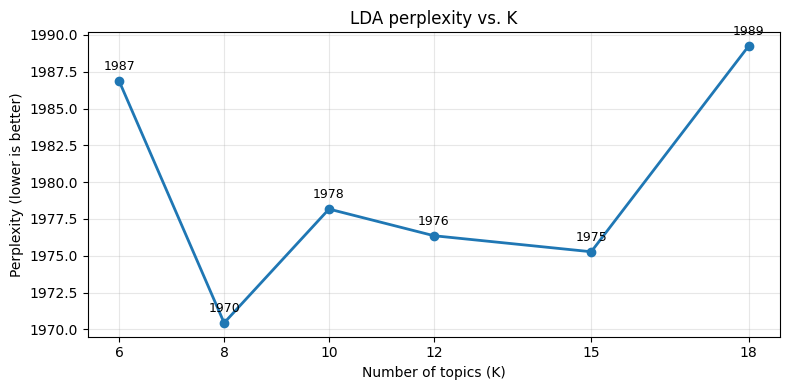

In [33]:
import matplotlib.pyplot as plt

ks = list(lda_results.keys())
perps = [lda_results[k]['perplexity'] for k in ks]

plt.figure(figsize=(8, 4))
plt.plot(ks, perps, marker='o', linewidth=2)
plt.xlabel('Number of topics (K)')
plt.ylabel('Perplexity (lower is better)')
plt.title('LDA perplexity vs. K')
plt.grid(True, alpha=0.3)
plt.xticks(ks)
for k, p in zip(ks, perps):
    plt.annotate(f'{p:.0f}', xy=(k, p), xytext=(0, 8),
                 textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [34]:
# Print top-10 words for every topic at every K, for qualitative comparison
for k in K_candidates:
    print("=" * 70)
    print(f"K = {k}  (perplexity = {lda_results[k]['perplexity']:.2f})")
    print("=" * 70)
    show_top_words(lda_results[k]['model'], feature_names, n_top=10)
    print()

K = 6  (perplexity = 1986.85)
Topic  0: project | rmb | system | order | power | game | development | operation | contract | energy
Topic  1: user | brand | content | marketing | ad | experience | consumer | advertiser | people | advertising
Topic  2: ai | billion | power | design | data | center | inventory | application | automotive | industrial
Topic  3: ai | cloud | data | enterprise | deal | security | model | capability | arr | billion
Topic  4: adjusted | segment | ebitda | slide | order | inventory | lower | acquisition | capital | prior
Topic  5: client | adjusted | ebitda | program | data | area | payment | experience | partner | process

K = 8  (perplexity = 1970.44)
Topic  0: user | game | rmb | content | live | billion | gaming | interpreted | language | foreign
Topic  1: brand | user | ad | advertiser | marketing | data | content | people | experience | consumer
Topic  2: ai | billion | design | power | inventory | center | data | automotive | application | industrial
Top

We finally Choose K=12 based on the coherence scores and interpretability of topics.

In [36]:
#Lock in final model with K=12
FINAL_K = 12
final_lda = lda_results[FINAL_K]['model']
print(f"Using LDA with K={FINAL_K} topics")
print(f"Perplexity: {lda_results[FINAL_K]['perplexity']:.2f}")

Using LDA with K=12 topics
Perplexity: 1976.36


Transform documents inyto topic distributions (400x12 matrix)

In [37]:
doc_topic_matrix = final_lda.transform(X)
print(f"Document-topic matrix shape: {doc_topic_matrix.shape}")
print(f"Each row sums to (should be ~1): "
      f"min={doc_topic_matrix.sum(axis=1).min():.3f}, "
      f"max={doc_topic_matrix.sum(axis=1).max():.3f}")

# Build the firm-level LDA feature dataframe
topic_cols = [f'topic_{i:02d}' for i in range(FINAL_K)]
lda_features = pd.DataFrame(doc_topic_matrix, columns=topic_cols)
lda_features.insert(0, 'companyname', firm_docs['companyname'].values)
lda_features.insert(0, 'companyid', firm_docs['companyid'].values)

print(f"\nLDA features shape: {lda_features.shape}")
print(f"\nFirst 3 firms:")
print(lda_features.head(3).round(3).to_string())

Document-topic matrix shape: (400, 12)
Each row sums to (should be ~1): min=1.000, max=1.000

LDA features shape: (400, 14)

First 3 firms:
   companyid          companyname  topic_00  topic_01  topic_02  topic_03  topic_04  topic_05  topic_06  topic_07  topic_08  topic_09  topic_10  topic_11
0      18749     Amazon.com, Inc.     0.016       0.2     0.040     0.106     0.063     0.183     0.064     0.000     0.034     0.293       0.0     0.000
1      19691  Cisco Systems, Inc.     0.000       0.0     0.183     0.000     0.046     0.000     0.086     0.073     0.000     0.328       0.0     0.284
2      21127    Intel Corporation     0.000       0.0     0.238     0.045     0.027     0.175     0.000     0.077     0.326     0.113       0.0     0.000


Identify AI-related topics

In [38]:
# Identify "AI-related" topics automatically based on presence of AI seed words
AI_SEED_WORDS = {
    'ai', 'ml', 'llm', 'gpt', 'generative', 'genai',
    'agent', 'agentic', 'copilot', 'chatbot',
    'artificial', 'intelligence', 'neural', 'inference',
    'automation', 'model',
}

def count_ai_words_in_topic(lda_model, topic_idx, feature_names, top_n=15):
    """Count how many AI seed words appear in a topic's top-N words."""
    topic = lda_model.components_[topic_idx]
    top_word_indices = topic.argsort()[-top_n:][::-1]
    top_words = {feature_names[i] for i in top_word_indices}
    return len(top_words & AI_SEED_WORDS), top_words & AI_SEED_WORDS

print(f"AI-word presence in top-15 of each topic:")
print(f"{'Topic':>6} | {'#AI':>4} | AI words present")
print("-" * 70)

ai_word_counts = []
for t in range(FINAL_K):
    count, words = count_ai_words_in_topic(final_lda, t, feature_names, top_n=15)
    ai_word_counts.append(count)
    print(f"Topic{t:>3} | {count:>4} | {sorted(words)}")

# Flag topics with 2+ AI seed words in their top-15 as "AI-related"
AI_TOPICS = [i for i, c in enumerate(ai_word_counts) if c >= 2]
print(f"\nAuto-identified AI-related topics (>=2 AI seeds in top-15): {AI_TOPICS}")

AI-word presence in top-15 of each topic:
 Topic |  #AI | AI words present
----------------------------------------------------------------------
Topic  0 |    0 | []
Topic  1 |    0 | []
Topic  2 |    1 | ['ai']
Topic  3 |    2 | ['ai', 'model']
Topic  4 |    0 | []
Topic  5 |    0 | []
Topic  6 |    0 | []
Topic  7 |    0 | []
Topic  8 |    1 | ['ai']
Topic  9 |    2 | ['ai', 'model']
Topic 10 |    0 | []
Topic 11 |    2 | ['ai', 'model']

Auto-identified AI-related topics (>=2 AI seeds in top-15): [3, 9, 11]


Manually set AI topics based on combined auto-detection + qualitative analysis

Includes both software-AI narratives (topics 3, 9, 11) and 
hardware/semiconductor-AI narratives (topics 2, 8)


In [40]:
AI_TOPICS = [2, 3, 8, 9, 11]

ai_topic_cols = [f'topic_{i:02d}' for i in AI_TOPICS]
lda_features['ai_topic_loading_sum'] = lda_features[ai_topic_cols].sum(axis=1)

print(f"AI-related topic columns being summed: {ai_topic_cols}")
print(f"\nai_topic_loading_sum distribution:")
print(lda_features['ai_topic_loading_sum'].describe().round(3))

print(f"\nTop 10 firms by ai_topic_loading_sum:")
print(lda_features.nlargest(10, 'ai_topic_loading_sum')[
    ['companyname', 'ai_topic_loading_sum']
].round(3).to_string(index=False))

print(f"\nBottom 10 firms by ai_topic_loading_sum:")
print(lda_features.nsmallest(10, 'ai_topic_loading_sum')[
    ['companyname', 'ai_topic_loading_sum']
].round(3).to_string(index=False))

AI-related topic columns being summed: ['topic_02', 'topic_03', 'topic_08', 'topic_09', 'topic_11']

ai_topic_loading_sum distribution:
count    400.000
mean       0.430
std        0.320
min        0.000
25%        0.124
50%        0.403
75%        0.718
max        1.000
Name: ai_topic_loading_sum, dtype: float64

Top 10 firms by ai_topic_loading_sum:
                       companyname  ai_topic_loading_sum
        CrowdStrike Holdings, Inc.                 1.000
          Himax Technologies, Inc.                 1.000
           Micron Technology, Inc.                 1.000
                      Rubrik, Inc.                 1.000
                 SentinelOne, Inc.                 1.000
                        CEVA, Inc.                 0.991
                 Astera Labs, Inc.                 0.988
                   Dynatrace, Inc.                 0.984
                    AvePoint, Inc.                 0.982
Credo Technology Group Holding Ltd                 0.963

Bottom 10 firms by

In [41]:
#top 30 words that are AI related
print("=" * 70)
print("Top-30 words in AI-related topics (for dictionary expansion)")
print("=" * 70)

for t in AI_TOPICS:
    topic = final_lda.components_[t]
    top_word_indices = topic.argsort()[-30:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    print(f"\nTopic {t}:")
    # Print in chunks of 10 for readability
    for i in range(0, 30, 10):
        print(f"  {' | '.join(top_words[i:i+10])}")

Top-30 words in AI-related topics (for dictionary expansion)

Topic 2:
  design | inventory | power | ai | data | center | industrial | sequentially | application | automotive
  silicon | mix | ramp | portfolio | billion | system | china | low | fourth | segment
  device | capacity | multiple | network | cycle | generation | course | outlook | volume | supply

Topic 3:
  client | data | ai | deal | digital | billion | area | capability | health | acquisition
  model | adjusted | top | feel | relationship | segment | obviously | add | seen | pleased
  benefit | expansion | core | pipeline | existing | pretty | certainly | set | innovation | already

Topic 8:
  billion | ai | china | production | leading | automotive | advanced | hbm | capacity | volume
  edge | order | percentage | supply | dram | test | profit | foundry | wafer | related
  development | actually | decrease | lower | application | process | system | car | model | global

Topic 9:
  ai | cloud | billion | data | infrastr

---

## Dictionary-based AI Narrative Measurement

The previous section constructed `ai_topic_loading_sum` via LDA — an
unsupervised discovery of AI-related topics. This section adds a complementary,
**dictionary-based** measure of AI narrative intensity.

**Why two methods?** LDA groups words by statistical co-occurrence, so its
"AI topic" can blend AI terminology with adjacent enterprise/hardware language.
A hand-curated dictionary, in contrast, measures AI narrative directly and
transparently: every counted word is explicitly chosen.

**Dictionary design.** The list below combines:
- Core AI concepts (ai, llm, generative, agent, ...)
- AI-specific hardware terms (hbm, gpu, tpu, accelerator)
- Named AI companies and products (nvidia, openai, chatgpt, claude, ...)


**Counting on raw text.** Counts are computed on the uncleaned `document`
field rather than the lemmatized/filtered `cleaned` field. This preserves
multi-word phrases (e.g., "artificial intelligence") and entity names
(e.g., "Claude") that the LDA preprocessing pipeline removes.

**Final output.** `ai_keyword_ratio` = (AI keyword occurrences) / (total words),
giving a comparable intensity score across firms of different document lengths.

---

In [43]:
#AI-DICT
AI_DICT = [
    # Core concepts
    'ai', 'ml', 'llm', 'gpt', 'genai',
    'generative', 'agent', 'agentic', 
    'copilot', 'chatbot',
    'artificial intelligence', 'machine learning',
    'neural', 'inference', 'automation',
    
    # Hardware (AI-specific)
    'hbm', 'gpu', 'tpu', 'accelerator',
    
    # Companies / Products
    'nvidia', 'openai', 'anthropic',
    'chatgpt', 'claude', 'gemini', 'huggingface',
]

In [44]:
#ai-keyword-count features
AI_PATTERNS = [re.compile(r'\b' + re.escape(w) + r'\b', re.IGNORECASE)
               for w in AI_DICT]


def count_ai_keywords(text):
    """Count total AI keyword occurrences in a raw (uncleaned) text."""
    text = str(text)
    return sum(pat.findall(text).__len__() for pat in AI_PATTERNS)


def count_ai_keywords_detail(text):
    """Return a dict of {keyword: count} for deeper inspection."""
    text = str(text)
    return {w: len(pat.findall(text)) 
            for w, pat in zip(AI_DICT, AI_PATTERNS)}


# Count AI mentions in each firm's RAW document (not cleaned)

print("Counting AI keyword occurrences per firm (using raw text)...")
t0 = time.time()
firm_docs['ai_keyword_count'] = firm_docs['document'].apply(count_ai_keywords)
firm_docs['raw_word_count']   = firm_docs['document'].str.split().str.len()
firm_docs['ai_keyword_ratio'] = (
    firm_docs['ai_keyword_count'] / firm_docs['raw_word_count']
)
print(f"Done in {time.time() - t0:.1f}s")

# Summary stats
print(f"\nai_keyword_count distribution:")
print(firm_docs['ai_keyword_count'].describe().round(1))

print(f"\nai_keyword_ratio distribution (ratio of AI words to total words):")
print(firm_docs['ai_keyword_ratio'].describe().round(4))

# Merge into lda_features
lda_features['ai_keyword_count'] = firm_docs['ai_keyword_count'].values
lda_features['ai_keyword_ratio'] = firm_docs['ai_keyword_ratio'].values

print(f"\nlda_features shape: {lda_features.shape}")

Counting AI keyword occurrences per firm (using raw text)...
Done in 2.4s

ai_keyword_count distribution:
count    400.0
mean      17.7
std       26.5
min        0.0
25%        1.0
50%        7.0
75%       23.0
max      240.0
Name: ai_keyword_count, dtype: float64

ai_keyword_ratio distribution (ratio of AI words to total words):
count    400.0000
mean       0.0030
std        0.0040
min        0.0000
25%        0.0002
50%        0.0013
75%        0.0039
max        0.0362
Name: ai_keyword_ratio, dtype: float64

lda_features shape: (400, 17)


Sanity check: Correlation between LDA-based and dictionary-based AI measures

In [45]:
# Top / Bottom 10 by ai_keyword_ratio
print("Top 10 firms by ai_keyword_ratio:")
print(lda_features.nlargest(10, 'ai_keyword_ratio')[
    ['companyname', 'ai_keyword_count', 'ai_keyword_ratio']
].round(4).to_string(index=False))

print(f"\nBottom 10 firms by ai_keyword_ratio:")
print(lda_features.nsmallest(10, 'ai_keyword_ratio')[
    ['companyname', 'ai_keyword_count', 'ai_keyword_ratio']
].round(4).to_string(index=False))

# Correlation between two AI measures: LDA topic loading vs keyword ratio
print(f"\n=== LDA vs Dictionary AI measure correlation ===")
corr = lda_features[['ai_topic_loading_sum', 'ai_keyword_ratio']].corr()
print(corr.round(3))

# Scatter: show where they agree and disagree
print(f"\n4-quadrant breakdown:")
print(f"  (using median splits)")
median_lda = lda_features['ai_topic_loading_sum'].median()
median_dict = lda_features['ai_keyword_ratio'].median()

high_lda_high_dict = (lda_features['ai_topic_loading_sum'] > median_lda) & \
                     (lda_features['ai_keyword_ratio'] > median_dict)
high_lda_low_dict  = (lda_features['ai_topic_loading_sum'] > median_lda) & \
                     (lda_features['ai_keyword_ratio'] <= median_dict)
low_lda_high_dict  = (lda_features['ai_topic_loading_sum'] <= median_lda) & \
                     (lda_features['ai_keyword_ratio'] > median_dict)
low_lda_low_dict   = (lda_features['ai_topic_loading_sum'] <= median_lda) & \
                     (lda_features['ai_keyword_ratio'] <= median_dict)

print(f"  High LDA + High Dict: {high_lda_high_dict.sum():3d} (both agree 'AI')")
print(f"  Low  LDA + Low  Dict: {low_lda_low_dict.sum():3d}  (both agree 'not AI')")
print(f"  High LDA + Low  Dict: {high_lda_low_dict.sum():3d}  (LDA says AI, dict disagrees)")
print(f"  Low  LDA + High Dict: {low_lda_high_dict.sum():3d}  (dict says AI, LDA disagrees)")

Top 10 firms by ai_keyword_ratio:
                companyname  ai_keyword_count  ai_keyword_ratio
         NVIDIA Corporation               240            0.0362
      Microsoft Corporation               160            0.0195
        Verint Systems Inc.                87            0.0185
                Baidu, Inc.               106            0.0170
               UiPath, Inc.                92            0.0170
       GSI Technology, Inc.                32            0.0161
DigitalOcean Holdings, Inc.               121            0.0157
                Five9, Inc.                90            0.0153
  Zoom Communications, Inc.               104            0.0145
              Alphabet Inc.               108            0.0135

Bottom 10 firms by ai_keyword_ratio:
                companyname  ai_keyword_count  ai_keyword_ratio
 Ballard Power Systems Inc.                 0               0.0
         Cirrus Logic, Inc.                 0               0.0
             Stratasys Ltd.     

### Build Topic Labels for LDA topics based on top words

In [46]:

TOPIC_LABELS = {
    0:  "Energy & Utilities",
    1:  "Advertising & Marketing",
    2:  "AI Semiconductor Design",
    3:  "AI Enterprise & Healthcare Services",
    4:  "Financial Reporting (Geographic)",
    5:  "Financial Reporting (Accounting)",
    6:  "Government & Defense",
    7:  "Project Execution & Capital",
    8:  "China AI Semiconductor Supply Chain",
    9:  "AI Cloud Infrastructure",
    10: "Chinese Gaming & Streaming",
    11: "AI SaaS & Cybersecurity",
}

AI_RELATED_TOPICS_SET = set(AI_TOPICS)  # [2, 3, 8, 9, 11]

# Build markdown content
md_lines = [
    "# LDA Topic Labels",
    "",
    "This document lists the human-curated labels for the 12 topics learned by",
    "the LDA model trained on 400 firm-level earnings-call documents.",
    "",
    "**Model**: `sklearn.decomposition.LatentDirichletAllocation`",
    "**Number of topics (K)**: 12",
    f"**Perplexity**: {lda_results[FINAL_K]['perplexity']:.2f}",
    "**Selection criterion**: K chosen by combining perplexity trajectory",
    "(flat minimum across K=8-15) with qualitative interpretability of top-15",
    "words per topic. K=12 yielded the cleanest separation between AI-related",
    "and non-AI-related narratives.",
    "",
    "## AI-related topics",
    "",
    "Topics **flagged as AI-related** (based on presence of AI seed vocabulary",
    "and qualitative analysis of AI narrative in top words):",
    "",
    f"- Topics: {sorted(AI_TOPICS)}",
    "",
    "These are summed into `ai_topic_loading_sum` as a single aggregate measure",
    "of AI narrative intensity per firm.",
    "",
    "## Topic dictionary",
    "",
    "For each topic: label, AI-flag, and the top 15 most representative words.",
    "",
]

for t in range(FINAL_K):
    topic = final_lda.components_[t]
    top_word_indices = topic.argsort()[-15:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    is_ai = "**[AI-related]**" if t in AI_RELATED_TOPICS_SET else ""

    md_lines.append(f"### Topic {t}: {TOPIC_LABELS[t]} {is_ai}")
    md_lines.append("")
    md_lines.append(f"Top 15 words: `{', '.join(top_words)}`")
    md_lines.append("")

# Write to file
md_content = "\n".join(md_lines)
OUTPUT_LABELS_PATH = Path('topic_labels.md')
OUTPUT_LABELS_PATH.write_text(md_content)
print(f"Saved topic labels to: {OUTPUT_LABELS_PATH.resolve()}")
print(f"File size: {OUTPUT_LABELS_PATH.stat().st_size} bytes")

# Show a preview
print(f"\n--- Preview (first 30 lines) ---")
print("\n".join(md_lines[:30]))

Saved topic labels to: /Users/harrymac/Desktop/Columbia S2/Machine Learning2/Group/deepseek-event-study-ml/code/nlp/03_lda/topic_labels.md
File size: 3239 bytes

--- Preview (first 30 lines) ---
# LDA Topic Labels

This document lists the human-curated labels for the 12 topics learned by
the LDA model trained on 400 firm-level earnings-call documents.

**Model**: `sklearn.decomposition.LatentDirichletAllocation`
**Number of topics (K)**: 12
**Perplexity**: 1976.36
**Selection criterion**: K chosen by combining perplexity trajectory
(flat minimum across K=8-15) with qualitative interpretability of top-15
words per topic. K=12 yielded the cleanest separation between AI-related
and non-AI-related narratives.

## AI-related topics

Topics **flagged as AI-related** (based on presence of AI seed vocabulary
and qualitative analysis of AI narrative in top words):

- Topics: [2, 3, 8, 9, 11]

These are summed into `ai_topic_loading_sum` as a single aggregate measure
of AI narrative intensity pe

### Final Save for this LDA model and topic labels, which will be used in the event study and for interpretation.

In [47]:
# Rename topic columns to include labels

def sanitize_label(label):
    """Convert label to a snake_case suffix safe for column names."""
    return re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')

rename_map = {
    f'topic_{i:02d}': f'topic_{i:02d}_{sanitize_label(TOPIC_LABELS[i])}'
    for i in range(FINAL_K)
}

lda_features_labeled = lda_features.rename(columns=rename_map)

# Final column order: IDs, topic loadings (with labels), AI aggregates
id_cols = ['companyid', 'companyname']
topic_cols_labeled = [rename_map[f'topic_{i:02d}'] for i in range(FINAL_K)]
ai_cols = ['ai_topic_loading_sum', 'ai_keyword_count', 'ai_keyword_ratio']

lda_features_labeled = lda_features_labeled[id_cols + topic_cols_labeled + ai_cols]

print(f"Final shape: {lda_features_labeled.shape}")
print(f"\nColumn list:")
for c in lda_features_labeled.columns:
    print(f"  {c}")
print(f"\nFirst 3 rows:")
print(lda_features_labeled.head(3).round(3).to_string())

# Save to CSV
OUTPUT_CSV = Path('firm_lda_features.csv')
lda_features_labeled.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved firm-level LDA features to: {OUTPUT_CSV.resolve()}")

Final shape: (400, 17)

Column list:
  companyid
  companyname
  topic_00_energy_utilities
  topic_01_advertising_marketing
  topic_02_ai_semiconductor_design
  topic_03_ai_enterprise_healthcare_services
  topic_04_financial_reporting_geographic
  topic_05_financial_reporting_accounting
  topic_06_government_defense
  topic_07_project_execution_capital
  topic_08_china_ai_semiconductor_supply_chain
  topic_09_ai_cloud_infrastructure
  topic_10_chinese_gaming_streaming
  topic_11_ai_saas_cybersecurity
  ai_topic_loading_sum
  ai_keyword_count
  ai_keyword_ratio

First 3 rows:
   companyid          companyname  topic_00_energy_utilities  topic_01_advertising_marketing  topic_02_ai_semiconductor_design  topic_03_ai_enterprise_healthcare_services  topic_04_financial_reporting_geographic  topic_05_financial_reporting_accounting  topic_06_government_defense  topic_07_project_execution_capital  topic_08_china_ai_semiconductor_supply_chain  topic_09_ai_cloud_infrastructure  topic_10_chinese_ga